In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("../dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [5]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

## Early Preprocessing ##

## Ubah ke Inspection Level ##

In [7]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [8]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [9]:
df_ins.duplicated().sum()

np.int64(0)

In [10]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

Text(0.5, 1.05, 'Feature Correlation')

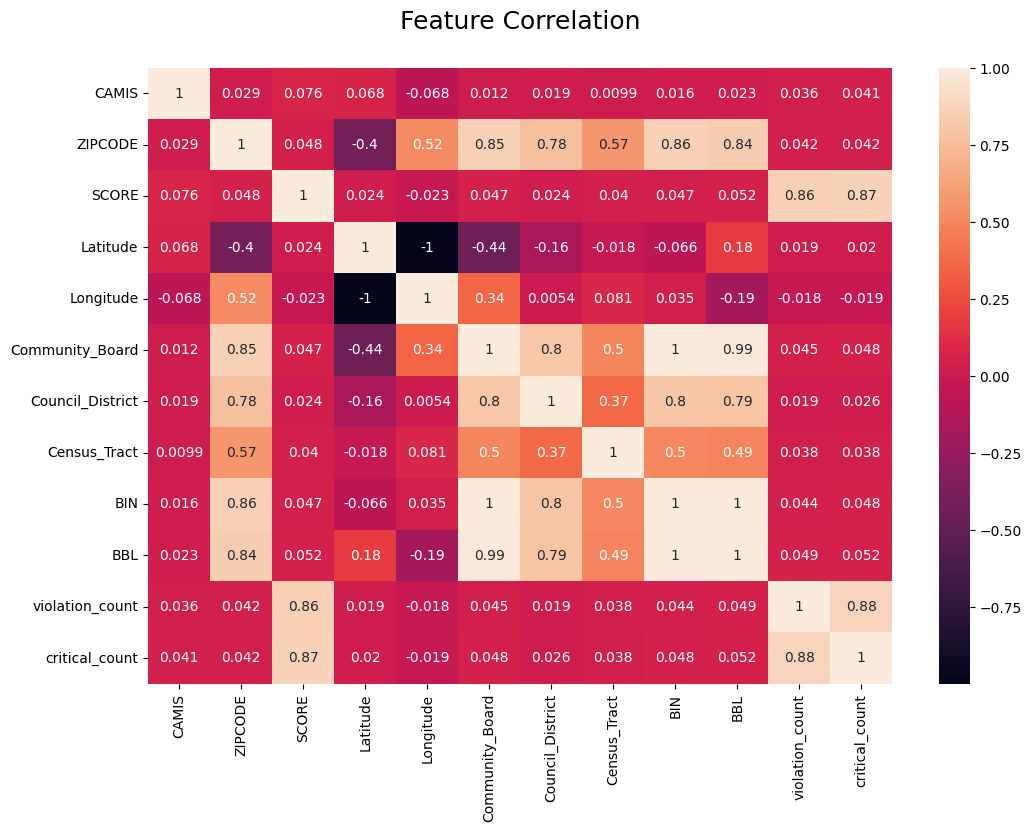

In [11]:
plt.figure(figsize=(12,8))
num_feature = df_ins.select_dtypes(include=['number'])
sns.heatmap(num_feature.corr(), annot=True, cmap="rocket")
plt.title('Feature Correlation', fontsize=18, y=1.05)

## Drop Null di SCORE ##

In [12]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()

In [13]:
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Score di dropna karena score itu kolom target jadi tidak bisa diisi apapun

## Ubah Tipe Data ##

In [14]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [15]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [16]:
df_base['inspection_dayofweek'].unique()

array([1, 4, 6, 2, 3, 0, 5], dtype=int32)

In [17]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [18]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [19]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [20]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [21]:
df_base["Community_Board"] = df_base["Community_Board"].astype("string")
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")

## Handle Missing Value Latitude Longitude ##

In [22]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [23]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [24]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [25]:
df_base["CUISINE_DESCRIPTION"] = df_base["CUISINE_DESCRIPTION"].astype("string")
df_base["INSPECTION TYPE"] = df_base["INSPECTION TYPE"].astype("string")

top_n_cuisine = 15
top_n_inspection = 5

top_cuisine = (
    df_base.loc[df_base["CUISINE_DESCRIPTION"] != "Unknown", "CUISINE_DESCRIPTION"]
    .value_counts()
    .head(top_n_cuisine)
    .index
)

top_inspection = (
    df_base.loc[df_base["INSPECTION TYPE"] != "Unknown", "INSPECTION TYPE"]
    .value_counts()
    .head(top_n_inspection)
    .index
)

df_base["CUISINE_DESCRIPTION"] = df_base["CUISINE_DESCRIPTION"].apply(
    lambda x: x if (x in top_cuisine or x == "Unknown") else "Other"
)

df_base["INSPECTION TYPE"] = df_base["INSPECTION TYPE"].apply(
    lambda x: x if (x in top_inspection or x == "Unknown") else "Other"
)

In [26]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

In [27]:
df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Other,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [28]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  object        
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68860 non-null  float64       
 7   Longitude             68860 non-null  float64       
 8   Community_Board       68860 non-null  string        
 9   INSPECTION TYPE       68860 non-null  object        
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

In [29]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Advanced Preprocessing ##

## Tambah Fitur Historis ##

In [30]:
df_hist = df_ins.sort_values(["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]).copy()

for col in ["SCORE", "violation_count", "critical_count"]:
    df_hist[col] = pd.to_numeric(df_hist[col], errors="coerce")

df_hist["GRADE"] = df_hist["GRADE"].astype("string")
df_hist["ACTION"] = df_hist["ACTION"].astype("string")

g = df_hist.groupby("CAMIS", group_keys=False)

df_hist["past_inspection_count"] = g.cumcount()

df_hist["prev_score"] = g["SCORE"].shift(1)
df_hist["avg_prev_score"] = g["SCORE"].transform(lambda s: s.shift(1).expanding().mean())
df_hist["max_prev_score"] = g["SCORE"].transform(lambda s: s.shift(1).expanding().max())
df_hist["last_3_avg_score"] = g["SCORE"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

df_hist["days_since_last_inspection"] = g["INSPECTION DATE"].diff().dt.days

df_hist["prev_violation_count"] = g["violation_count"].shift(1)
df_hist["avg_prev_violation_count"] = g["violation_count"].transform(
    lambda s: s.shift(1).expanding().mean()
)

df_hist["prev_critical_count"] = g["critical_count"].shift(1)
df_hist["avg_prev_critical_count"] = g["critical_count"].transform(
    lambda s: s.shift(1).expanding().mean()
)

df_hist["ever_had_critical_before"] = (
    g["critical_count"].transform(lambda s: s.shift(1).gt(0).cummax())
    .fillna(False)
    .astype(int)
)

df_hist["prev_grade"] = g["GRADE"].shift(1).fillna("Unknown")
df_hist["prev_action"] = g["ACTION"].shift(1).fillna("Unknown")

df_hist["repeat_offender_before"] = (
    g["critical_count"].transform(lambda s: s.shift(1).gt(0).cumsum().ge(2))
    .fillna(False)
    .astype(int)
)

In [31]:
hist_features = [
    "prev_score",
    "avg_prev_score",
    "max_prev_score",
    "last_3_avg_score",
    "past_inspection_count",
    "days_since_last_inspection",
    "prev_violation_count",
    "avg_prev_violation_count",
    "prev_critical_count",
    "avg_prev_critical_count",
    "ever_had_critical_before",
    "prev_grade",
    "prev_action",
    "repeat_offender_before"
]

df_hist_features = df_hist[
    ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"] + hist_features
].copy()

df_base = df_base.merge(
    df_hist_features,
    on=["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"],
    how="left"
)

In [32]:
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "prev_score", "avg_prev_score", "max_prev_score",
    "past_inspection_count", "days_since_last_inspection",
    "prev_grade", "prev_action"
]].head(10)

,CAMIS,INSPECTION DATE,SCORE,prev_score,avg_prev_score,max_prev_score,past_inspection_count,days_since_last_inspection,prev_grade,prev_action
0,30075445,2023-08-01,38.0,NaN,NaN,NaN,0.0,NaN,Unknown,Unknown
1,30075445,2023-08-22,12.0,38.0,38.0,38.0,1.0,21.0,Unknown,Violations were cited in the following area(s).
2,30075445,2024-11-08,10.0,12.0,25.0,38.0,2.0,444.0,A,Violations were cited in the following area(s).
3,30075445,2026-02-27,7.0,10.0,20.0,38.0,3.0,476.0,A,Violations were cited in the following area(s).
4,30191841,2023-04-23,10.0,NaN,NaN,NaN,0.0,NaN,Unknown,Unknown
5,30191841,2024-11-20,24.0,10.0,10.0,10.0,1.0,577.0,A,Violations were cited in the following area(s).
6,30191841,2025-02-20,10.0,24.0,17.0,24.0,2.0,92.0,Unknown,Violations were cited in the following area(s).
7,40356018,2024-04-16,0.0,NaN,NaN,NaN,0.0,NaN,Unknown,Unknown
8,40356018,2025-09-17,10.0,0.0,0.0,0.0,1.0,519.0,A,No violations were recorded at the time of thi...
9,40356483,2023-11-16,35.0,NaN,NaN,NaN,0.0,NaN,Unknown,Unknown


In [33]:
df_base[hist_features].isna().sum()

prev_score                    29125
avg_prev_score                29125
max_prev_score                29125
last_3_avg_score              29125
past_inspection_count          3067
days_since_last_inspection    29125
prev_violation_count          29125
avg_prev_violation_count      29125
prev_critical_count           29125
avg_prev_critical_count       29125
ever_had_critical_before       3067
prev_grade                     3067
prev_action                    3067
repeat_offender_before         3067
dtype: int64

In [34]:
df_base

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek,prev_score,avg_prev_score,max_prev_score,last_3_avg_score,past_inspection_count,days_since_last_inspection,prev_violation_count,avg_prev_violation_count,prev_critical_count,avg_prev_critical_count,ever_had_critical_before,prev_grade,prev_action,repeat_offender_before
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Unknown,Unknown,0.0
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1,38.0,38.0,38.0,38.0,1.0,21.0,3.0,3.0,2.0,2.000000,1.0,Unknown,Violations were cited in the following area(s).,0.0
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4,12.0,25.0,38.0,25.0,2.0,444.0,3.0,3.0,1.0,1.500000,1.0,A,Violations were cited in the following area(s).,1.0
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4,10.0,20.0,38.0,20.0,3.0,476.0,3.0,3.0,1.0,1.333333,1.0,A,Violations were cited in the following area(s).,1.0
4,30191841,2023-04-23,10.0,Other,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Unknown,Unknown,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68855,50181422,2026-02-25,47.0,Other,Manhattan,10019.0,40.764938,-73.987896,104.0,Other,2026,2,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
68856,50181505,2026-02-12,37.0,Other,Manhattan,10128.0,40.780145,-73.950077,108.0,Pre-permit (Operational) / Initial Inspection,2026,2,1,3,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Unknown,Unknown,0.0
68857,50181726,2026-02-11,2.0,Bakery Products/Desserts,Queens,11101.0,40.747272,-73.926419,402.0,Other,2026,2,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
68858,50182075,2026-02-24,0.0,American,Brooklyn,11231.0,40.685568,-74.002423,306.0,Other,2026,2,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


In [35]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek', 'prev_score',
       'avg_prev_score', 'max_prev_score', 'last_3_avg_score',
       'past_inspection_count', 'days_since_last_inspection',
       'prev_violation_count', 'avg_prev_violation_count',
       'prev_critical_count', 'avg_prev_critical_count',
       'ever_had_critical_before', 'prev_grade', 'prev_action',
       'repeat_offender_before'],
      dtype='object')

## Handle Missing Value untuk Fitur Historis ##

In [36]:
df_base["has_history"] = (df_base["past_inspection_count"] > 0).astype(int)

In [37]:
count_like_cols = [
    "past_inspection_count",
    "prev_violation_count",
    "avg_prev_violation_count",
    "prev_critical_count",
    "avg_prev_critical_count",
    "ever_had_critical_before",
    "repeat_offender_before"
]

for col in count_like_cols:
    df_base[col] = df_base[col].fillna(0)

In [38]:
df_base["ever_had_critical_before"] = df_base["ever_had_critical_before"].fillna(0).astype(int)
df_base["repeat_offender_before"] = df_base["repeat_offender_before"].fillna(0).astype(int)

In [39]:
score_hist_cols = [
    "prev_score",
    "avg_prev_score",
    "max_prev_score",
    "last_3_avg_score"
]

for col in score_hist_cols:
    df_base[col] = df_base[col].fillna(-1)

In [40]:
df_base["days_since_last_inspection"] = df_base["days_since_last_inspection"].fillna(-1)

In [41]:
cat_hist_cols = ["prev_grade", "prev_action"]

for col in cat_hist_cols:
    df_base[col] = df_base[col].astype("string")
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)
    df_base[col] = df_base[col].fillna("Unknown")

In [42]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68860 entries, 0 to 68859
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CAMIS                       68860 non-null  int64         
 1   INSPECTION DATE             68860 non-null  datetime64[ns]
 2   SCORE                       68860 non-null  float64       
 3   CUISINE_DESCRIPTION         68860 non-null  object        
 4   BORO                        68860 non-null  category      
 5   ZIPCODE                     68860 non-null  category      
 6   Latitude                    68860 non-null  float64       
 7   Longitude                   68860 non-null  float64       
 8   Community_Board             68860 non-null  string        
 9   INSPECTION TYPE             68860 non-null  object        
 10  inspection_year             68860 non-null  int32         
 11  inspection_month            68860 non-null  int32     

**Penjelasan:**
- has_history buat tandain pernah diinspeksi g
- kolom past_inspection_count, prev_violation_count, avg_prev_violation_count, prev_critical_count, avg_prev_critical_count, ever_had_critical_before, repeat_offender_before
- fitur prev_score, avg_prev_score, max_prev_score, last_3_avg_score diisi dengan -1 artinya belum ada riwayat
- day_since_last_inspection diisi -1 jika belum ada riwayat
- fitur prev_grade dan prev_action diisi unknown klo blm ad riwayat

## Buat jadi DataFrame untuk Model ##

In [43]:
target = "SCORE"

helper_cols = ["CAMIS", "INSPECTION DATE"]

numeric_features = [
    "Latitude",
    "Longitude",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek",
    "prev_score",
    "avg_prev_score",
    "max_prev_score",
    "last_3_avg_score",
    "past_inspection_count",
    "days_since_last_inspection",
    "prev_violation_count",
    "avg_prev_violation_count",
    "prev_critical_count",
    "avg_prev_critical_count"
]

categorical_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Community_Board",
    "INSPECTION TYPE",
    "prev_grade",
    "prev_action"
]

binary_features = [
    "ever_had_critical_before",
    "repeat_offender_before",
    "has_history"
]

feature_cols = numeric_features + categorical_features + binary_features

df_model = df_base[helper_cols + feature_cols + [target]].copy()

print("Shape:", df_model.shape)
print("\nMissing values:")
print(df_model[feature_cols + [target]].isna().sum().sort_values(ascending=False))

Shape: (68860, 29)

Missing values:
Latitude                      0
Longitude                     0
inspection_year               0
inspection_month              0
inspection_quarter            0
inspection_dayofweek          0
prev_score                    0
avg_prev_score                0
max_prev_score                0
last_3_avg_score              0
past_inspection_count         0
days_since_last_inspection    0
prev_violation_count          0
avg_prev_violation_count      0
prev_critical_count           0
avg_prev_critical_count       0
CUISINE_DESCRIPTION           0
BORO                          0
ZIPCODE                       0
Community_Board               0
INSPECTION TYPE               0
prev_grade                    0
prev_action                   0
ever_had_critical_before      0
repeat_offender_before        0
has_history                   0
SCORE                         0
dtype: int64


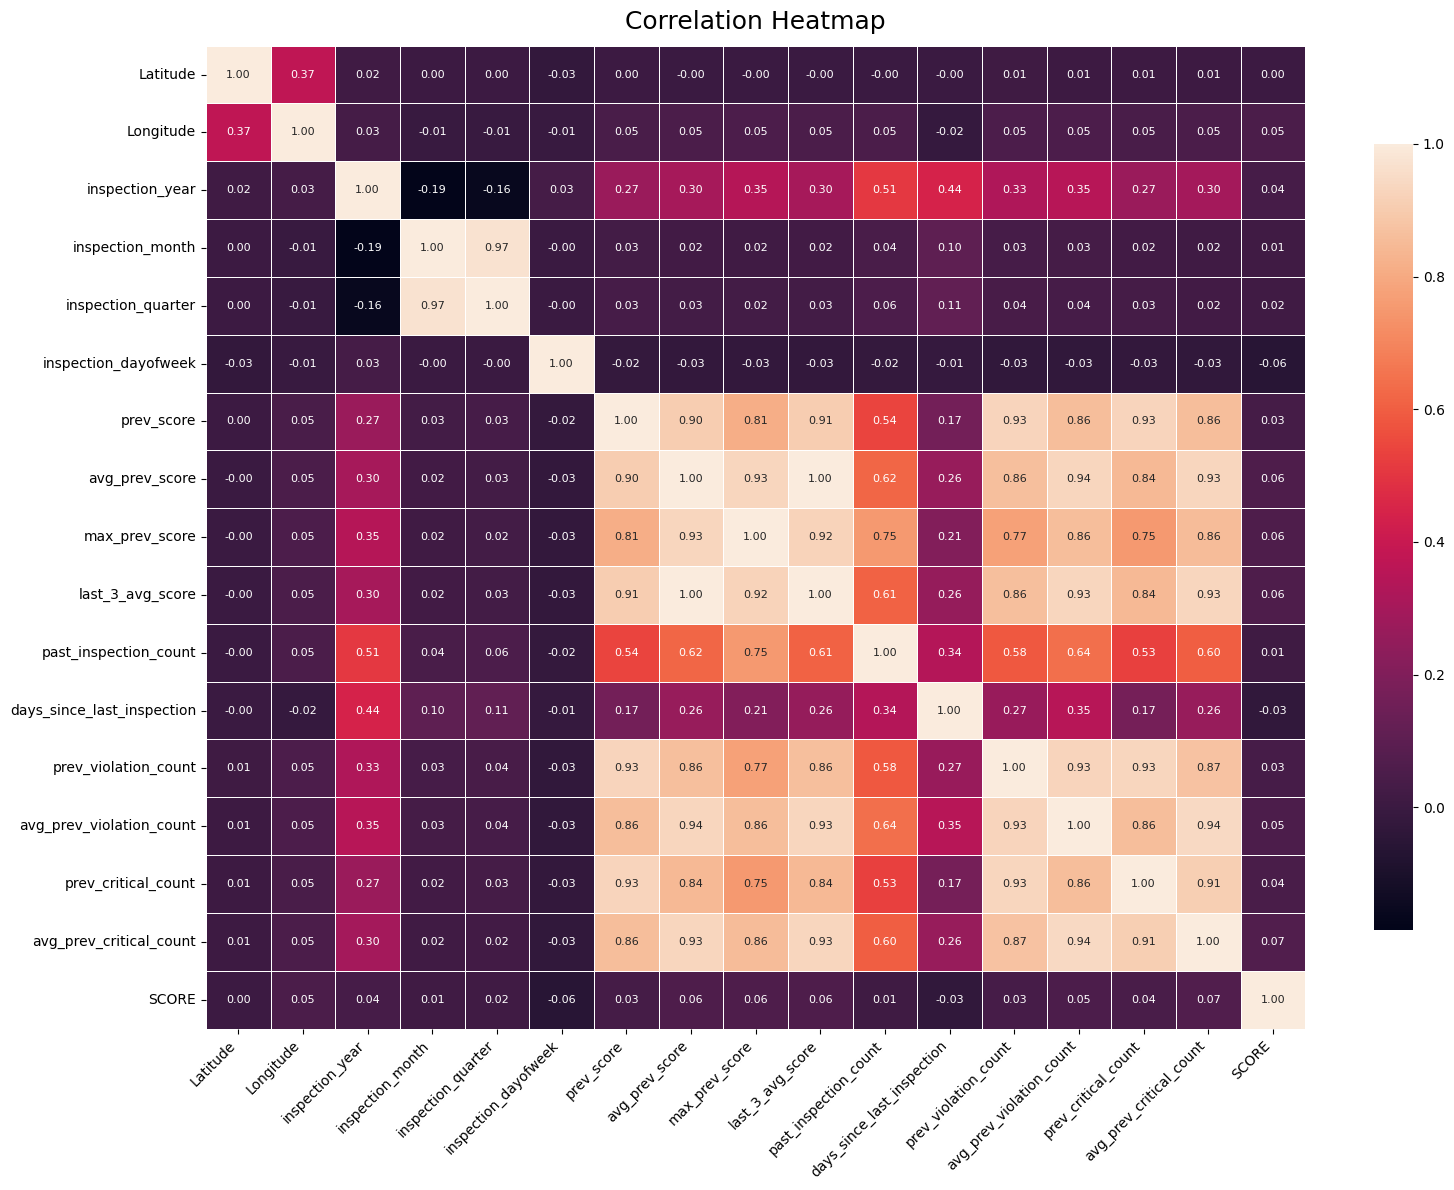

In [47]:
corr = df_model[numeric_features + [target]].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    linewidths=0.5,
    square=False,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap", fontsize=18, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()